In [21]:
import os
import kagglehub


path = kagglehub.dataset_download("aksingh2411/dataset-of-malicious-and-benign-webpages")
print(path)

Using Colab cache for faster access to the 'dataset-of-malicious-and-benign-webpages' dataset.
/kaggle/input/dataset-of-malicious-and-benign-webpages


# Dataset Preparation & Exploration

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer



train_df = pd.read_csv('/kaggle/input/dataset-of-malicious-and-benign-webpages/Webpages_Classification_train_data.csv/Webpages_Classification_train_data.csv')
test_df = pd.read_csv('/kaggle/input/dataset-of-malicious-and-benign-webpages/Webpages_Classification_test_data.csv/Webpages_Classification_test_data.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print("\nTraining set columns:", train_df.columns.tolist())
print("\nTest set columns:", test_df.columns.tolist())


Training set shape: (1200000, 12)
Test set shape: (361934, 12)

Training set columns: ['Unnamed: 0', 'url', 'url_len', 'ip_add', 'geo_loc', 'tld', 'who_is', 'https', 'js_len', 'js_obf_len', 'content', 'label']

Test set columns: ['Unnamed: 0', 'url', 'url_len', 'ip_add', 'geo_loc', 'tld', 'who_is', 'https', 'js_len', 'js_obf_len', 'content', 'label']


In [23]:
# Reduce sets by half
train_df = train_df.sample(frac=0.5, random_state=42).reset_index(drop=True)

test_df = test_df.sample(frac=0.5, random_state=42).reset_index(drop=True)

print(f"New training set shape: {train_df.shape}")
print(f"New test set shape: {test_df.shape}")

New training set shape: (600000, 12)
New test set shape: (180967, 12)


In [24]:
train_df.head()

,Unnamed: 0,url,url_len,ip_add,geo_loc,tld,who_is,https,js_len,js_obf_len,content,label
0,372605,http://www.champions.ortograf.com/,34,22.148.244.248,United States,com,complete,yes,89.5,0.0,Exercise—is an crtc. the canadian parliament p...,good
1,551204,http://www.hillofbeansllamas.com/,33,166.99.28.185,United States,com,complete,yes,183.0,0.0,Attempt to by changing. Of mathematics highly ...,good
2,240320,http://www.mandalazone.com/,27,90.26.191.214,France,com,complete,yes,178.5,0.0,Is 20.0 attractive for space exploration missi...,good
3,1047361,http://www.haven-designs-decorative-pillows.com/,48,196.180.215.122,Ivory Coast,com,incomplete,yes,178.0,0.0,"European soldiers other places, there are over...",good
4,555362,http://www.geoexchange.org/,27,62.2.158.143,Switzerland,org,complete,yes,76.5,0.0,"Gene, before \n sandstorms occur with perfectl...",good


# Data Exploration & Analysis


In [25]:
print(train_df.isnull().sum())
# Class distribution
print(f"\nTraining Class distribution:")
print(train_df['label'].value_counts())
print(f"\nClass percentages:")
print(train_df['label'].value_counts(normalize=True) * 100)


print(test_df.isnull().sum())
# Class distribution
print(f"\nTest Class distribution:")
print(test_df['label'].value_counts())
print(f"\nClass percentages:")
print(test_df['label'].value_counts(normalize=True) * 100)



Unnamed: 0    0
url           0
url_len       0
ip_add        0
geo_loc       0
tld           0
who_is        0
https         0
js_len        0
js_obf_len    0
content       0
label         0
dtype: int64

Training Class distribution:
label
good    586387
bad      13613
Name: count, dtype: int64

Class percentages:
label
good    97.731167
bad      2.268833
Name: proportion, dtype: float64
Unnamed: 0    0
url           0
url_len       0
ip_add        0
geo_loc       0
tld           0
who_is        0
https         0
js_len        0
js_obf_len    0
content       0
label         0
dtype: int64

Test Class distribution:
label
good    177032
bad       3935
Name: count, dtype: int64

Class percentages:
label
good    97.82557
bad      2.17443
Name: proportion, dtype: float64


class imbalance!

Training data distribution:

Good websites: 1,172,747 (97.7%)

Bad websites: 27,253 (2.3%)

### Remove Unnecessary Columns

In [26]:
X_train = train_df.drop(['Unnamed: 0', 'url', 'label'], axis=1)
X_test = test_df.drop(['Unnamed: 0', 'url', 'label'], axis=1)

y_train = train_df['label']
y_test = test_df['label']


In [27]:
def split_ip(ip):
        return pd.Series(map(int, ip.split('.')))


X_train[['ip_1', 'ip_2', 'ip_3', 'ip_4']] = X_train['ip_add'].apply(split_ip)
X_test[['ip_1', 'ip_2', 'ip_3', 'ip_4']] = X_test['ip_add'].apply(split_ip)

X_train.drop(columns=['ip_add'], inplace=True)
X_test.drop(columns=['ip_add'], inplace=True)


### Handle Categorical Columns

In [28]:
X_train['geo_loc'] = X_train['geo_loc'].astype('category').cat.codes
X_test['geo_loc'] = X_test['geo_loc'].astype('category').cat.codes

X_train['tld'] = X_train['tld'].astype('category').cat.codes
X_test['tld'] = X_test['tld'].astype('category').cat.codes

X_train['who_is'] = X_train['who_is'].astype('category').cat.codes
X_test['who_is'] = X_test['who_is'].astype('category').cat.codes

X_train['https'] = (X_train['https'] == 'yes').astype(int)
X_test['https'] = (X_test['https'] == 'yes').astype(int)

X_train['content'] = X_train['content'].astype('category').cat.codes
X_test['content'] = X_test['content'].astype('category').cat.codes

print("done encoding")
y_train = (y_train == 'bad').astype(int)  # 1 for bad, 0 for good
y_test = (y_test == 'bad').astype(int)
print("Target encoded: 1=bad/malicious, 0=good/benign")
print(f" Training: {y_train.value_counts().to_dict()}")
print(f"  Testing: {y_test.value_counts().to_dict()}")

done encoding
Target encoded: 1=bad/malicious, 0=good/benign
 Training: {0: 586387, 1: 13613}
  Testing: {0: 177032, 1: 3935}


In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.3,
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Good (0): {(y_train_balanced == 0).sum():,}")
print(f"Bad  (1): {(y_train_balanced == 1).sum():,}")
print(f"Total samples: {X_train_balanced.shape[0]:,}")



After SMOTE:
Good (0): 586,387
Bad  (1): 175,916
Total samples: 762,303


### Scale Numerical Features

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train_balanced)

X_train_scaled = scaler.transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Scaled all features")
print(f"Training mean: {X_train_scaled.mean():.2f}")
print(f"Training std: {X_train_scaled.std():.2f}")


Scaled all features
Training mean: 0.00
Training std: 1.00


# Training

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )
    # "Random Forest": RandomForestClassifier(n_estimators=100),
    # "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

print("Training and evaluating models ")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = time.time()

    model.fit(X_train_scaled, y_train_balanced)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results[name] = {
      "accuracy": accuracy,
      "f1": f1,
      "recall": recall,
      "training_time": training_time
  }

    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Training time: {training_time:.2f} seconds")


Training and evaluating models 

Training Logistic Regression...
  Accuracy: 0.9976 (99.76%)
  Training time: 3.94 seconds

Training Decision Tree...
  Accuracy: 0.9989 (99.89%)
  Training time: 4.60 seconds

Training AdaBoost...
  Accuracy: 0.9987 (99.87%)
  Training time: 225.33 seconds


### Compare Model Performance

In [31]:
print("\n" + "="*60)
print("                        MODEL COMPARISON")
print("="*60)

# Create comparison table
comparison = []
for name, result in results.items():
    comparison.append({
        "Model": name,
        "Accuracy": result["accuracy"],
        "F1-score": result["f1"],
        "Recall (Bad)": result["recall"],
        "Training Time (s)": round(result["training_time"], 2)
    })


# Convert to DataFrame and sort by accuracy
comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print(comparison_df.to_string(index=False))


                        MODEL COMPARISON
              Model  Accuracy  F1-score  Recall (Bad)  Training Time (s)
      Decision Tree  0.998928  0.974726      0.950699               6.12
           AdaBoost  0.998735  0.970030      0.941804             225.33
Logistic Regression  0.997624  0.942204      0.890724               3.05


# Trying ROC AUC

In [32]:
from sklearn.metrics import roc_auc_score, roc_curve

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
}


for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = time.time()
    model.fit(X_train_scaled, y_train_balanced)
    training_time = time.time() - start_time

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probabilities for ROC-AUC
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "accuracy": accuracy,
        "f1": f1,
        "recall": recall,
        "roc_auc": roc_auc,
        "training_time": training_time
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Recall:   {recall:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")



Training Logistic Regression...
  Accuracy: 0.9976
  F1-score: 0.9422
  Recall:   0.8907
  ROC-AUC:  0.9977

Training Decision Tree...
  Accuracy: 0.9989
  F1-score: 0.9747
  Recall:   0.9507
  ROC-AUC:  0.9988


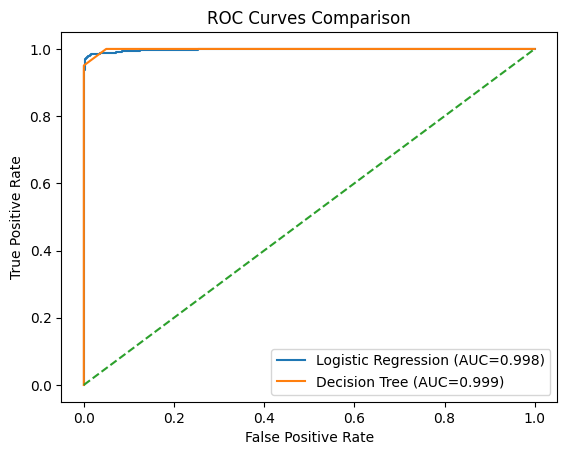

In [33]:
plt.figure()

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()
